# ALiBi — Solution

Reference implementation for `02_alibi_exercise.ipynb`.

## Setup

In [1]:
import torch
import matplotlib.pyplot as plt

## Solution 1 — Head slopes

In [2]:
def get_alibi_slopes(n_heads):
    """Return shape (n_heads,) tensor of geometric slopes 2^-1, 2^-2, ..."""
    return 1 / torch.pow(2, torch.arange(1, n_heads + 1))

In [3]:
get_alibi_slopes(8)

tensor([0.5000, 0.2500, 0.1250, 0.0625, 0.0312, 0.0156, 0.0078, 0.0039])

## Solution 2 — Bias matrix

The bias is `-slope * |i - j|`. We compute the absolute distance matrix once and broadcast across heads.

In [4]:
def alibi_bias(seq_len, slopes):
    distances = (torch.arange(seq_len)[None, :] - torch.arange(seq_len)[:, None]).abs()
    return -slopes[:, None, None] * distances

## Solution 3 — Length extrapolation

The bias formula has no learned parameters and no hard cap — it works at any sequence length. Below: confirm shapes scale, the per-step magnitude is right, and the curves look sensible.

In [5]:
print('shape at seq_len=128 :', alibi_bias(128,  get_alibi_slopes(4)).shape)
print('shape at seq_len=2048:', alibi_bias(2048, get_alibi_slopes(4)).shape)

shape at seq_len=128 : torch.Size([4, 128, 128])
shape at seq_len=2048: torch.Size([4, 2048, 2048])


In [6]:
# Head 0 has slope 0.5, so bias at distance 100 should be -50.
b_short = alibi_bias(128,  get_alibi_slopes(4))
b_long  = alibi_bias(2048, get_alibi_slopes(4))
print('bias[head=0, pos=0, dist=100] @ 128: ', b_short[0, 0, 100].item())
print('bias[head=0, pos=0, dist=100] @ 2048:', b_long[0, 0, 100].item())
assert torch.allclose(b_short[0, 0, 100], torch.tensor(-50.0))

bias[head=0, pos=0, dist=100] @ 128:  -50.0
bias[head=0, pos=0, dist=100] @ 2048: -50.0


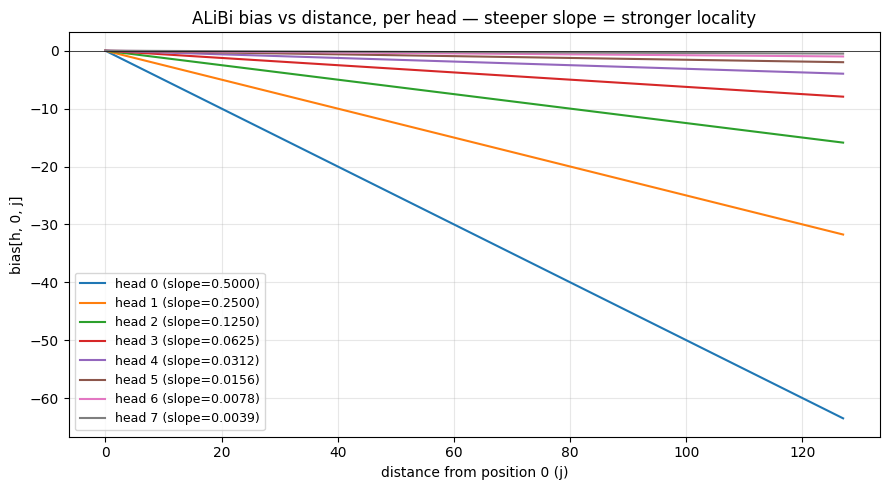

In [7]:
# Plot bias[h, 0, :] vs distance for each head — different slopes give
# different rates of locality enforcement.
slopes = get_alibi_slopes(8)
bias = alibi_bias(seq_len=128, slopes=slopes)   # (8, 128, 128)

fig, ax = plt.subplots(figsize=(9, 5))
for h in range(8):
    ax.plot(bias[h, 0, :].numpy(), label=f'head {h} (slope={slopes[h]:.4f})')

ax.set_xlabel('distance from position 0 (j)')
ax.set_ylabel('bias[h, 0, j]')
ax.set_title('ALiBi bias vs distance, per head — steeper slope = stronger locality')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='lower left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()